Using KNN algorithm to predict whether a person have diabetes or not.  

In [129]:
# import libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# load dataset
dataset = pd.read_csv('diabetes.csv')
print(len(dataset))

# Check dataset for missing values and duplicates
print(dataset.head())
print(dataset.isna().sum())
print(dataset.duplicated().sum())

In [197]:
# 1. List the columns where a 0 is medically impossible
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Replace 0 with NaN so Pandas recognizes them as missing
dataset[zero_columns] = dataset[zero_columns].replace(0, np.nan)

# 3. Fill those NaN blanks with the median value of each column
for col in zero_columns:
    dataset[col] = dataset[col].fillna(dataset[col].median())

In [200]:
#defien target and features
X = dataset.drop("Outcome", axis = 1)
y = dataset["Outcome"]

#split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [201]:
# Feature scaling - converting different variable into the same scale (-1 to 1)
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [121]:
#calculate K - rule of thumnb - square root of number of samples in training set
#import math
#math.sqrt(len(y_test))
#12.409673645990857 - we will try with K = 11 and K = 13

In [202]:
# Define model 
classifier = KNeighborsClassifier(n_neighbors = 27, metric = 'euclidean', 
                                  p = 2, algorithm = "auto")
classifier.fit(X_train, y_train)

# Predicting the test set results
y_pred = classifier.predict(X_test)
#y_pred
#Evaluating the model
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[97 10]
 [19 28]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       107
           1       0.74      0.60      0.66        47

    accuracy                           0.81       154
   macro avg       0.79      0.75      0.76       154
weighted avg       0.81      0.81      0.81       154



Cross validation to find best possible k

The best K value is: 9 with an accuracy of 0.7525
Final Test Accuracy: 0.8247
Mean Cross-Validated Accuracy: 0.7371


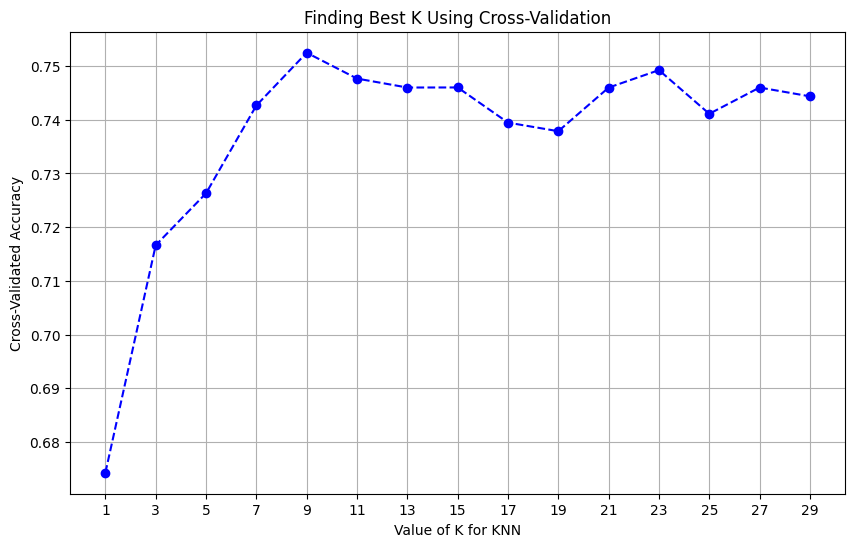

In [203]:
# Range of K values to test
k_values = [k for k in range(1, 31) if k % 2 != 0]
cv_scores = []

for k in k_values:
    # Initialize the KNN classifier with current K
    knn = KNeighborsClassifier(n_neighbors=k, metric = "euclidean", p = 2, algorithm = "auto")
    
    # 5-fold cross-validation on the training set
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    
    # Store the average accuracy
    cv_scores.append(np.mean(scores))


# Find the K with highest average accuracy
best_index = np.argmax(cv_scores)
best_k = k_values[best_index]
print(f"The best K value is: {best_k} with an accuracy of {cv_scores[best_index]:.4f}")


final_knn = KNeighborsClassifier(n_neighbors=best_k, metric = "euclidean", p = 2, algorithm = "auto")
final_knn.fit(X_train, y_train)
print(f"Final Test Accuracy: {final_knn.score(X_test, y_test):.4f}")

print(f"Mean Cross-Validated Accuracy: {np.mean(cv_scores):.4f}")


plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='dashed', color='blue')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Finding Best K Using Cross-Validation')
plt.xticks(k_values)
plt.grid(True)
plt.show()

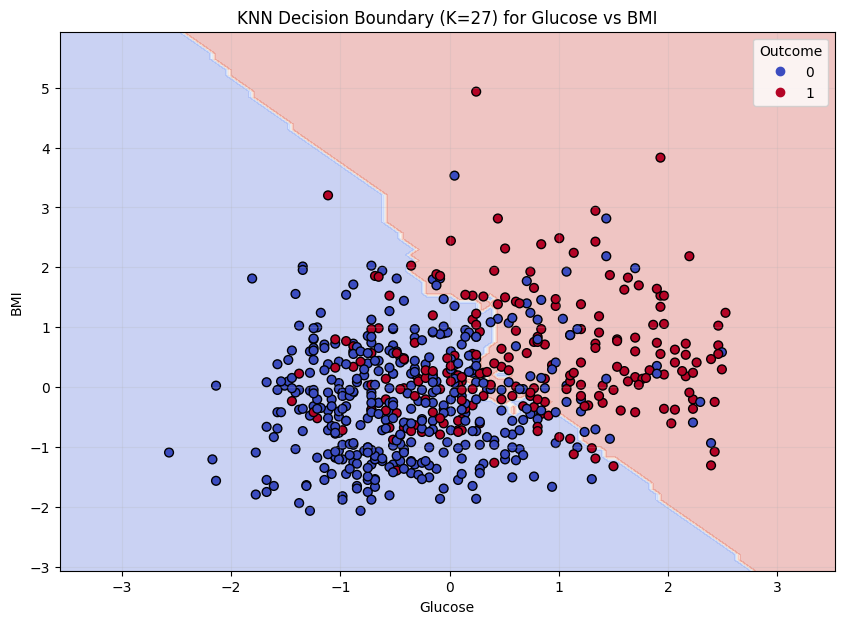

In [204]:
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Use column number indexes instead of names
# Index 1 is Glucose, Index 5 is BMI
feat_1_idx = 1
feat_2_idx = 5

# Slice the NumPy array using integer positions
X_plot = X_train[:, [feat_1_idx, feat_2_idx]]

# 2. Train a model on just those two features
knn_2d = KNeighborsClassifier(n_neighbors=27, metric="euclidean", p=2, algorithm="auto")
knn_2d.fit(X_plot, y_train)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 7))

# Draw the background color zones
DecisionBoundaryDisplay.from_estimator(
    knn_2d,
    X_plot,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.3,
    ax=ax
)

# Scatter the actual training data points on top
# (Using array slicing here too)
scatter = ax.scatter(
    X_plot[:, 0], 
    X_plot[:, 1], 
    c=y_train, 
    cmap="coolwarm", 
    edgecolors="k", 
    s=40
)

# Labels and styling
ax.set_xlabel("Glucose")
ax.set_ylabel("BMI")
ax.set_title("KNN Decision Boundary (K=27) for Glucose vs BMI")
plt.legend(*scatter.legend_elements(), title="Outcome")
plt.grid(True, alpha=0.2)
plt.show()